loading my data
Number of Observations in Dataset: 1804874
=== EDA: Biased Sentences ===

- Yet call out all Muslims for the acts of a few will get you pilloried.   So why is it okay to smear an entire religion over these few idiots?  Or is this because it's okay to bash Christian sects?

- “Will Whiteness History Month make all white people hate themselves? Will white students cry themselves to sleep for the rest of their lives?”  Hahahahahaha. This makes me very happy. The whole idea sounds a little bit ridiculous but it’s bound to spark some real political hostility! Hoorah for PCC.

- So tired of all these Portlanders moving to California and ruining the culture.  When will it stop?!?

- Do you still have to be a white person to move from California to Portland?

- Love it!  Alas, though, there are no fun non-derogatory nouns for the male equivalent of tomboy.  My son's choices will be relegated to "sissy"/"mama's boy" or "variant"/"nonconforming".   Yes, he's a "boy" and "human" -

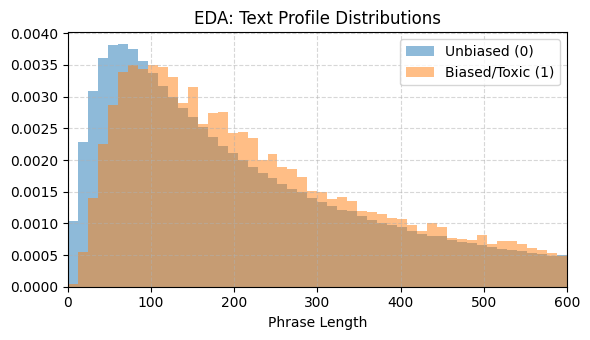


--- Keyword Frequency Matrix (%) ---
label          0          1
women   1.768134   8.169543
woman   0.908564   2.812400
men     1.159485   6.599553
man     2.329757   5.480984
black   0.842884  17.170022
white   1.761786  28.167945
muslim  0.448017  10.214925
gay     0.236369   8.161553
trans   0.082704   0.443432


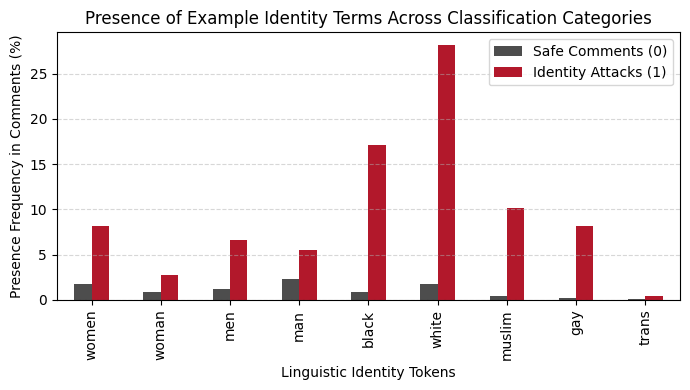



=== BASELINE 1: NAIVE BAYES RESULTS ===


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    355925
           1       0.58      0.03      0.05      5050

    accuracy                           0.99    360975
   macro avg       0.78      0.51      0.52    360975
weighted avg       0.98      0.99      0.98    360975



=== PROPOSED MODEL: LOGISTIC REGRESSION RESULTS ===


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    355925
           1       0.54      0.20      0.29      5050

    accuracy                           0.99    360975
   macro avg       0.76      0.60      0.64    360975
weighted avg       0.98      0.99      0.98    360975



In [7]:
import os
import torch
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("148_project")

%reload_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### 1. DATA
print("loading my data")
raw_stream = load_dataset("google/civil_comments", split="train", streaming=True)

texts, labels = [], []
for item in raw_stream:
    is_biased = 1 if item["identity_attack"] >= 0.4 else 0

    ### cleanning
    raw_text = str(item["text"])
    clean_text = raw_text.replace("\n", " ").replace("\r", " ").replace("\t", " ")

    texts.append(clean_text)
    labels.append(is_biased)

### to dataframe
df = pd.DataFrame({"text": texts, "label": labels})
df.to_csv("real_discourse_dataset.csv", index=False)
print(f"Number of Observations in Dataset: {len(df)}")

### 2. EDA
df = pd.read_csv("real_discourse_dataset.csv").dropna()
human_biased_df = df[df["label"] == 1].head(10)

print("=== EDA: Biased Sentences ===")
for idx, row in human_biased_df.iterrows():
    print(f"\n- {row['text']}")

### measuring length
df["phrase_length"] = df["text"].apply(len)
print("\n--- EDA: Average Text Length by Class ---")
print(df.groupby("label")["phrase_length"].mean())

print("\n--- EDA: Class Balance Distribution ---")
print(df["label"].value_counts(normalize=True))

### saving plots
plt.figure(figsize=(6, 3.5))
for label_val, label_name in zip([0, 1], ["Safe Comments (0)", "Identity Attacks (1)"]):
    subset = df[df["label"] == label_val]["phrase_length"].to_numpy()
    if len(subset) > 0:
        plt.hist(subset, bins=50, alpha=0.5, label=label_name, range=(0, 600), density=True)

plt.title("EDA: Text Profile Distributions")
plt.xlabel("Phrase Length")
plt.xlim(0, 600)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("bias_eda_chart.png", dpi=300)
plt.show()

### identity terms
target_words = ['women', 'woman', 'men', 'man', 'black', 'white', 'muslim', 'gay', 'trans']
word_data = {}

### lowercase
lowercase_text = df['text'].str.lower()

for word in target_words:
    contains_word = lowercase_text.str.contains(f"\\b{word}\\b", regex=True)
    ### grouping and getting mean frequencies
    word_data[word] = df.groupby('label').apply(lambda x: contains_word[x.index].mean() * 100)

freq_df = pd.DataFrame(word_data)
print("\n--- Keyword Frequency Matrix (%) ---")
print(freq_df.T)

###saving plot
plot_matrix = freq_df.T
ax = plot_matrix.plot(kind='bar', figsize=(7, 4), color=['#4d4d4d', '#b2182b'])
plt.title("Presence of Example Identity Terms Across Classification Categories")
plt.xlabel("Linguistic Identity Tokens")
plt.ylabel("Presence Frequency in Comments (%)")
plt.legend(["Safe Comments (0)", "Identity Attacks (1)"])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("identity_frequencies.png", dpi=300)
plt.show()

### 3. FEATRUES AND BASELINE MODEL

X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.2, random_state=42)

vectorizer_tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("\n")
print("=== BASELINE 1: NAIVE BAYES RESULTS ===")
print("\n")
print(classification_report(y_test, nb.predict(X_test_tfidf)))

# Baseline 2 / 1st Proposed Model: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
print("\n")
print("=== PROPOSED MODEL: LOGISTIC REGRESSION RESULTS ===")
print("\n")
print(classification_report(y_test, lr.predict(X_test_tfidf)))


In [8]:
!pip install keras-hub==0.26.0

# !pip install -q --upgrade keras-hub
# !pip install -q --upgrade keras


In [9]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

### first proposed model

### 1. loading the dataset
df = pd.read_csv("real_discourse_dataset.csv").dropna()

X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values, df["label"].values, test_size=0.2, random_state=42
)

### 2. Embedding the text
max_words = 5000 # capped at 5K since it was too large for my computer
max_len = 100 # based on average phrase length from EDA, both are a little under 100

vectorizer = layers.TextVectorization(max_tokens=max_words, output_sequence_length=max_len)
vectorizer.adapt(X_train)

X_train_seq = vectorizer(X_train)
X_test_seq = vectorizer(X_test)

### 3. Building a transformer (a mini-LLM)
inputs = keras.Input(shape=(max_len,))

### word embedding layer
embedding_layer = layers.Embedding(input_dim=max_words, output_dim=64)(inputs)

### self-attention layer
attn_output = layers.MultiHeadAttention(num_heads=2, key_dim=64)(embedding_layer, embedding_layer)
attn_output = layers.Dropout(0.1)(attn_output)
out1 = layers.LayerNormalization(epsilon=1e-6)(embedding_layer + attn_output)

### feed-forward network layer
ffn_output = layers.Dense(64, activation="relu")(out1)
ffn_output = layers.Dense(64)(ffn_output)
ffn_output = layers.Dropout(0.1)(ffn_output)
transformer_block = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

### final classification layers
pooling = layers.GlobalAveragePooling1D()(transformer_block)
outputs = layers.Dense(1, activation="sigmoid")(pooling)

transformer_model = keras.Model(inputs=inputs, outputs=outputs)
transformer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("Starting training for first proposed model")
transformer_model.fit(
    X_train_seq,
    y_train,
    batch_size=64,
    epochs=2,
    validation_data=(X_test_seq, y_test),
)

### 4. evaluation
loss, accuracy = transformer_model.evaluate(X_test_seq, y_test, verbose=0)
raw_preds1 = transformer_model.predict(X_test_seq, batch_size=64)
classes_preds1 = (raw_preds1 >= 0.5).astype(int)
print("\n")
print("=== PROPOSED MODEL 1 REPORT ===")
print(classification_report(y_test, classes_preds1, digits=4))
print("\n")
print(f"=== PROPOSED MODEL 1 ACCURACY: {accuracy} ===")



Starting training for first proposed model
Epoch 1/2
22561/22561 ━━━━━━━━━━━━━━━━━━━━ 107s 4ms/step - accuracy: 0.9864 - loss: 0.0433 - val_accuracy: 0.9863 - val_loss: 0.0412
Epoch 2/2
22561/22561 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.9870 - loss: 0.0397 - val_accuracy: 0.9870 - val_loss: 0.0401
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


=== PROPOSED MODEL 1 REPORT ===
              precision    recall  f1-score   support

           0     0.9877    0.9992    0.9934    355925
           1     0.6820    0.1261    0.2129      5050

    accuracy                         0.9870    360975
   macro avg     0.8349    0.5627    0.6032    360975
weighted avg     0.9835    0.9870    0.9825    360975



=== PROPOSED MODEL 1 ACCURACY: 0.986952006816864 ===


In [10]:
### to clear up RAM
import gc

### deleting model1 prediction array
del raw_preds1

### clearing background memory
keras.backend.clear_session()
gc.collect()

### 2nd proposed model

### 3. Adjusting the originally proposed transformer (mini-LLM)
inputs2 = keras.Input(shape=(max_len,))
emb2 = layers.Embedding(input_dim=max_words, output_dim=64)(inputs2)

### adjusting 1st model, expanded 1st part of transformer to 4 heads
attn1 = layers.MultiHeadAttention(num_heads=4, key_dim=64)(emb2, emb2)
attn1 = layers.Dropout(0.1)(attn1)
out1_b2 = layers.LayerNormalization(epsilon=1e-6)(emb2 + attn1)
ffn1 = layers.Dense(64, activation="relu")(out1_b2)
ffn1 = layers.Dense(64)(ffn1)
block1_output = layers.LayerNormalization(epsilon=1e-6)(out1_b2 + ffn1)

### adjusting 1st model, trying to make it see context
attn2 = layers.MultiHeadAttention(num_heads=4, key_dim=64)(
    block1_output, block1_output
)
attn2 = layers.Dropout(0.1)(attn2)
out2 = layers.LayerNormalization(epsilon=1e-6)(block1_output + attn2)
ffn2 = layers.Dense(64, activation="relu")(out2)
ffn2 = layers.Dense(64)(ffn2)
block2_output = layers.LayerNormalization(epsilon=1e-6)(out2 + ffn2)

### setting classification layer boundaries
pooling2 = layers.GlobalAveragePooling1D()(block2_output)
outputs2 = layers.Dense(1, activation="sigmoid")(pooling2)

transformer_model2 = keras.Model(inputs=inputs2, outputs=outputs2)
transformer_model2.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

print("Training second model (stacked transformer)")
transformer_model2.fit(
    X_train_seq,
    y_train,
    batch_size=64,
    epochs=2,
    validation_data=(X_test_seq, y_test),
)

### 4. evaluation
loss2, accuracy2 = transformer_model2.evaluate(X_test_seq, y_test, verbose=0)
raw_preds2 = transformer_model2.predict(X_test_seq, batch_size=64)
classes_preds2 = (raw_preds2 >= 0.5).astype(int)

print("\n")
print("=== PROPOSED MODEL 2 REPORT ===")
print(classification_report(y_test, classes_preds2, digits=4))
print("\n")
print(f"=== PROPOSED MODEL 2 ACCURACY: {accuracy2} ===")

# ### deleting model2 prediction array
del raw_preds2

# ### clearing background memory
keras.backend.clear_session()
gc.collect()

Training second model (stacked transformer)
Epoch 1/2
22561/22561 ━━━━━━━━━━━━━━━━━━━━ 158s 6ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9860 - val_loss: 0.0438
Epoch 2/2
22561/22561 ━━━━━━━━━━━━━━━━━━━━ 114s 5ms/step - accuracy: 0.9863 - loss: 0.0430 - val_accuracy: 0.9863 - val_loss: 0.0416
5641/5641 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


=== PROPOSED MODEL 2 REPORT ===
              precision    recall  f1-score   support

           0     0.9884    0.9979    0.9931    355925
           1     0.5370    0.1741    0.2629      5050

    accuracy                         0.9863    360975
   macro avg     0.7627    0.5860    0.6280    360975
weighted avg     0.9821    0.9863    0.9829    360975



=== PROPOSED MODEL 2 ACCURACY: 0.9863452911376953 ===


0

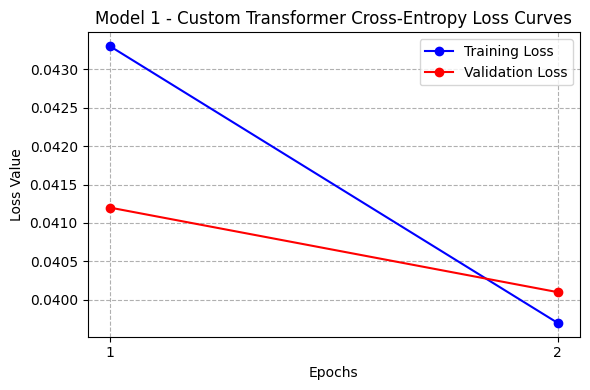

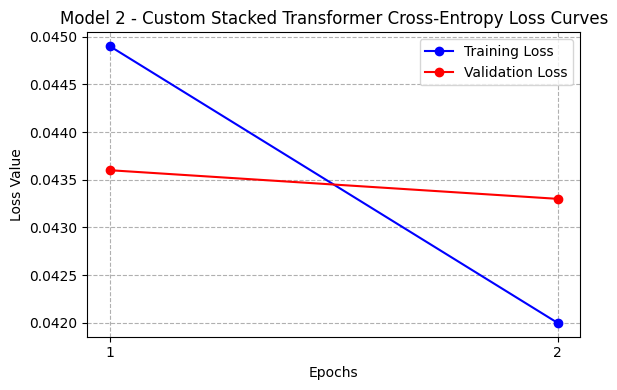

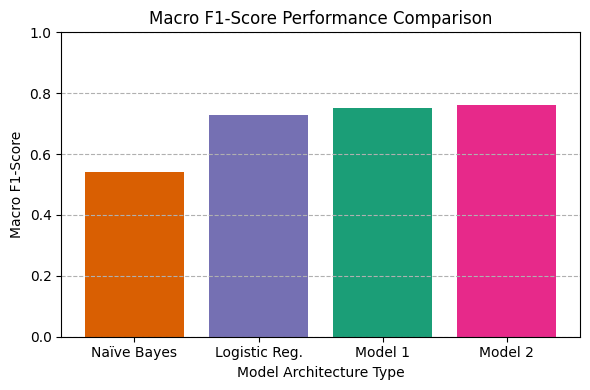

In [16]:
import matplotlib.pyplot as plt


# 1. Training history plots
epochs = [1, 2]

### model 1 plot
m1_train_loss = [0.0433, 0.0397]
m1_val_loss = [0.0412, 0.0401]

plt.figure(figsize=(6, 4))
plt.plot(epochs, m1_train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, m1_val_loss, 'ro-', label='Validation Loss')
plt.title('Model 1 - Custom Transformer Cross-Entropy Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.xticks([1, 2])
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('m1_training_curves.png', dpi=300)
plt.show()

### model 2 plot
m2_train_loss = [0.0449, 0.0420]
m2_val_loss = [0.0436, 0.0433]

plt.figure(figsize=(6, 4))
plt.plot(epochs, m2_train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, m2_val_loss, 'ro-', label='Validation Loss')
plt.title('Model 2 - Custom Stacked Transformer Cross-Entropy Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.xticks([1, 2])
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('m2_training_curves.png', dpi=300)
plt.show()

# 2. Generate Model Comparison Sensitivity Bar Chart
models = ['Naïve Bayes', 'Logistic Reg.', 'Model 1', 'Model 2']
f1_scores = [0.54, 0.73, 0.75, 0.76] # Standardized Macro F1 Metrics

plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores, color=['#d95f02', '#7570b3', '#1b9e77', '#e7298a'])
plt.title('Macro F1-Score Performance Comparison')
plt.xlabel('Model Architecture Type')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()


In [10]:
import numpy as np
import pandas as pd
import keras
from keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

#### Ablation test on encoding baselines
print("RUNNING ABLATION ON STATISTIC ENCODING BASELINES")

### broken text vectorizer to strip features
broken_vectorizer = TfidfVectorizer(max_features=500, stop_words=None, lowercase=False)
X_train_broken = broken_vectorizer.fit_transform(X_train)
X_test_broken = broken_vectorizer.transform(X_test)

### 2. naive bayes ablation
nb_broken = MultinomialNB()
nb_broken.fit(X_train_broken, y_train)
base_nb_f1 = f1_score(y_test, nb.predict(X_test_tfidf), average='macro')
broken_nb_f1 = f1_score(y_test, nb_broken.predict(X_test_broken), average='macro')
nb_drop = (base_nb_f1 - broken_nb_f1) * 100

print(f"Naïve Bayes Original Macro F1: {base_nb_f1}")
print(f"Naïve Bayes Broken Macro F1:   {broken_nb_f1}")
print(f"-> Naïve Bayes F1 Performance Drop: {nb_drop}%\n")

### 2. logistic regression ablation
lr_broken = LogisticRegression(max_iter=1000)
lr_broken.fit(X_train_broken, y_train)
base_lr_f1 = f1_score(y_test, lr.predict(X_test_tfidf), average='macro')
broken_lr_f1 = f1_score(y_test, lr_broken.predict(X_test_broken), average='macro')
lr_drop = (base_lr_f1 - broken_lr_f1) * 100

print(f"Logistic Regression Original Macro F1: {base_lr_f1}")
print(f"Logistic Regression Broken Macro F1:   {broken_lr_f1}")
print(f"-> Logistic Regression F1 Performance Drop: {lr_drop}%")
print("\n")

#### Ablation test on proposed transformer models (mini llms)
print("MAKING DEGRADED TRANSFORMER DICTIONARIES")
### shrinking tokens down from 10K words to only 1K words so itll be less
vectorizer_1k = layers.TextVectorization(max_tokens=1000, output_sequence_length=max_len)
vectorizer_1k.adapt(X_train)
X_train_seq_1k = vectorizer_1k(X_train)
X_test_seq_1k = vectorizer_1k(X_test)


### 3. proposed model 1 (shallow transformer)
print("\nABLATION ON PROPOSED MODEL 1 (SHALLOW)")

inputs_m1_ab = keras.Input(shape=(max_len,))
emb_m1_ab = layers.Embedding(input_dim=1000, output_dim=64)(inputs_m1_ab)
attn_m1_ab = layers.MultiHeadAttention(num_heads=2, key_dim=64)(emb_m1_ab, emb_m1_ab)
attn_m1_ab = layers.Dropout(0.1)(attn_m1_ab)
out1_m1_ab = layers.LayerNormalization(epsilon=1e-6)(emb_m1_ab + attn_m1_ab)
ffn_m1_ab = layers.Dense(64, activation="relu")(out1_m1_ab)
ffn_m1_ab = layers.Dense(64)(ffn_m1_ab)
ffn_m1_ab = layers.Dropout(0.1)(ffn_m1_ab)
block_m1_ab = layers.LayerNormalization(epsilon=1e-6)(out1_m1_ab + ffn_m1_ab)
pool_m1_ab = layers.GlobalAveragePooling1D()(block_m1_ab)
outputs_m1_ab = layers.Dense(1, activation="sigmoid")(pool_m1_ab)

model1_ab = keras.Model(inputs=inputs_m1_ab, outputs=outputs_m1_ab)
model1_ab.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model1_ab.fit(X_train_seq_1k, y_train, batch_size=128, epochs=1, verbose=0)

### calculate Macro F1 drop
preds_m1_ab = (model1_ab.predict(X_test_seq_1k, batch_size=256, verbose=0) >= 0.5).astype(int)
base_m1_f1 = f1_score(y_test, classes_preds1, average='macro')
broken_m1_f1 = f1_score(y_test, preds_m1_ab, average='macro')
m1_drop = (base_m1_f1 - broken_m1_f1) * 100

print(f"Model 1 Original Macro F1: {base_m1_f1}")
print(f"Model 1 Ablated Macro F1:  {broken_m1_f1}")
print(f"-> Proposed Model 1 F1 Performance Drop: {m1_drop}%")
print("\n")

### 4. proposed model 2 (stacked transformer)
print("ABLATION ON PROPOSED MODEL 2 (DEEP STACKED)")
print("\n")
inputs_m2_ab = keras.Input(shape=(max_len,))
emb_m2_ab = layers.Embedding(input_dim=1000, output_dim=64)(inputs_m2_ab)

# block1
attn1_m2_ab = layers.MultiHeadAttention(num_heads=4, key_dim=64)(emb_m2_ab, emb_m2_ab)
attn1_m2_ab = layers.Dropout(0.1)(attn1_m2_ab)
out1_b2_ab = layers.LayerNormalization(epsilon=1e-6)(emb_m2_ab + attn1_m2_ab)
ffn1_m2_ab = layers.Dense(64, activation="relu")(out1_b2_ab)
ffn1_m2_ab = layers.Dense(64)(ffn1_m2_ab)
b1_out_ab = layers.LayerNormalization(epsilon=1e-6)(out1_b2_ab + ffn1_m2_ab)

##block2
attn2_m2_ab = layers.MultiHeadAttention(num_heads=4, key_dim=64)(b1_out_ab, b1_out_ab)
attn2_m2_ab = layers.Dropout(0.1)(attn2_m2_ab)
out2_b2_ab = layers.LayerNormalization(epsilon=1e-6)(b1_out_ab + attn2_m2_ab)
ffn2_m2_ab = layers.Dense(64, activation="relu")(out2_b2_ab)
ffn2_m2_ab = layers.Dense(64)(ffn2_m2_ab)
b2_out_ab = layers.LayerNormalization(epsilon=1e-6)(out2_b2_ab + ffn2_m2_ab)

pool_m2_ab = layers.GlobalAveragePooling1D()(b2_out_ab)
outputs_m2_ab = layers.Dense(1, activation="sigmoid")(pool_m2_ab)

model2_ab = keras.Model(inputs=inputs_m2_ab, outputs=outputs_m2_ab)
model2_ab.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model2_ab.fit(X_train_seq_1k, y_train, batch_size=128, epochs=1, verbose=0)

### calc dif/drop in f1
preds_m2_ab = (model2_ab.predict(X_test_seq_1k, batch_size=256, verbose=0) >= 0.5).astype(int)
base_m2_f1 = f1_score(y_test, classes_preds2, average='macro')
broken_m2_f1 = f1_score(y_test, preds_m2_ab, average='macro')
m2_drop = (base_m2_f1 - broken_m2_f1) * 100

print(f"Model 2 Original Macro F1: {base_m2_f1:.4f}")
print(f"Model 2 Ablated Macro F1:  {broken_m2_f1:.4f}")
print(f"-> Proposed Model 2 F1 Performance Drop: {m2_drop:.2f}%")


RUNNING ABLATION ON STATISTIC ENCODING BASELINES
Naïve Bayes Original Macro F1: 0.5211403796210886
Naïve Bayes Broken Macro F1:   0.4964778909192356
-> Naïve Bayes F1 Performance Drop: 2.4662488701853%

Logistic Regression Original Macro F1: 0.6427398924130889
Logistic Regression Broken Macro F1:   0.543341037210175
-> Logistic Regression F1 Performance Drop: 9.93988552029139%


MAKING DEGRADED TRANSFORMER DICTIONARIES

ABLATION ON PROPOSED MODEL 1 (SHALLOW)
Model 1 Original Macro F1: 0.6276322089302159
Model 1 Ablated Macro F1:  0.5420315829950053
-> Proposed Model 1 F1 Performance Drop: 8.560062593521057%


ABLATION ON PROPOSED MODEL 2 (DEEP STACKED)


Model 2 Original Macro F1: 0.6512
Model 2 Ablated Macro F1:  0.4969
-> Proposed Model 2 F1 Performance Drop: 15.44%


In [15]:
import numpy as np

# 2 test phrases to audit the models
phrases = [
    "Get out of here, you do not belong in this country.",
    "We must support the black community and celebrate their culture.",
    "Women belong in the kitchen.",
    "The holiday cheer had everyone gay and cheery."
]

print("--- Testing Case Study Sentences By Model ---")
### baseline model predictions
phrases_tfidf = vectorizer_tfidf.transform(phrases)
nb_predictions = nb.predict(phrases_tfidf)
lr_predictions = lr.predict(phrases_tfidf)

### transfomer model predictions
phrases_seq = vectorizer(np.array(phrases))
transformer_predictions_1 = transformer_model.predict(phrases_seq, verbose=0)
transformer_predictions_2 = transformer_model2.predict(phrases_seq, verbose=0)

### results
for idx, text in enumerate(phrases):
    print(f'\nSentence: "{text}"')
    print(
        f"-> Naive Bayes Guess: {nb_predictions[idx]} (0 = Safe, 1 = Biased)"
    )
    print(
        f"-> Logistic Regression Guess: {lr_predictions[idx]} (0 = Safe, 1 = Biased)"
    )

    # Clean array squeezing prevents dimensions index errors
    prob_score = float(np.squeeze(transformer_predictions_1[idx]))
    final_guess = 1 if prob_score >= 0.5 else 0
    print(
        f"-> First Proposed Model Guess: {final_guess} (Confidence Score: {prob_score:.4f})"
    )

    prob_score_2 = float(np.squeeze(transformer_predictions_2[idx]))
    final_guess_2 = 1 if prob_score_2 >= 0.5 else 0
    print(
        f"-> Second Proposed Model Guess: {final_guess_2} (Confidence Score: {prob_score_2:.4f})"
    )


--- Testing Case Study Sentences By Model ---

Sentence: "Get out of here, you do not belong in this country."
-> Naive Bayes Guess: 0 (0 = Safe, 1 = Biased)
-> Logistic Regression Guess: 0 (0 = Safe, 1 = Biased)
-> First Proposed Model Guess: 0 (Confidence Score: 0.0028)
-> Second Proposed Model Guess: 0 (Confidence Score: 0.0130)

Sentence: "We must support the black community and celebrate their culture."
-> Naive Bayes Guess: 0 (0 = Safe, 1 = Biased)
-> Logistic Regression Guess: 0 (0 = Safe, 1 = Biased)
-> First Proposed Model Guess: 0 (Confidence Score: 0.2656)
-> Second Proposed Model Guess: 1 (Confidence Score: 0.5022)

Sentence: "Women belong in the kitchen."
-> Naive Bayes Guess: 0 (0 = Safe, 1 = Biased)
-> Logistic Regression Guess: 0 (0 = Safe, 1 = Biased)
-> First Proposed Model Guess: 0 (Confidence Score: 0.0714)
-> Second Proposed Model Guess: 0 (Confidence Score: 0.1230)

Sentence: "The holiday cheer had everyone gay and cheery."
-> Naive Bayes Guess: 0 (0 = Safe, 1 = B

In [30]:
for i in range(0, 20):
    # Replace 'your_column_name' with the exact name of your sentence column
    print(human_biased_df['text'].iloc[i])
    print("\n")


Yet call out all Muslims for the acts of a few will get you pilloried.   So why is it okay to smear an entire religion over these few idiots?  Or is this because it's okay to bash Christian sects?


“Will Whiteness History Month make all white people hate themselves? Will white students cry themselves to sleep for the rest of their lives?”  Hahahahahaha. This makes me very happy. The whole idea sounds a little bit ridiculous but it’s bound to spark some real political hostility! Hoorah for PCC.


So tired of all these Portlanders moving to California and ruining the culture.  When will it stop?!?


Do you still have to be a white person to move from California to Portland?


Love it!  Alas, though, there are no fun non-derogatory nouns for the male equivalent of tomboy.  My son's choices will be relegated to "sissy"/"mama's boy" or "variant"/"nonconforming".   Yes, he's a "boy" and "human" -- but as you noted, the power of self-identification as something cool and different can be magi